In [36]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

def scat(x, y, c,marker):
    return ax.scatter(x, y*100, c=c, ls='-', cmap=cmap, norm=norm, s=30, marker=marker
                     )
import pyccl as ccl
import sys
sys.path.append('../forecasts/')
import fisher_matrix_bao_SuEisenstein
sys.path.append('../survey_design/')
import _tracer_spectroscopic_efficiency
import _survey_design_telescope_metrics
import _surveys
import _survey_design_science_metrics

h=0.677
deltac=1.686
H0=100*h
c_ls=300*10**3
nlim=10000
n_s=0.968

cosmo = ccl.Cosmology(Omega_c=0.27, Omega_b=0.045, h=h, A_s=2.1e-9, n_s=n_s,transfer_function='boltzmann_camb')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
import pickle
def save_pickle(dat, filename, **kwargs):
    file = open(filename,'wb')
    pickle.dump(dat, file)
    file.close()
def load(filename, **kwargs):
    with open(filename, 'rb') as fin:
        return pickle.load(fin, **kwargs)

In [38]:
path = '../survey_design/telescope_and_science_metrics/'

In [39]:
survey_design_bright = load(path + 'survey_design_Bright_desilike.pkl')
survey_design_grey = load(path + 'survey_design_Grey_desilike.pkl')
survey_design_dark_qso = load(path + 'survey_design_Dark_qso_only.pkl')
survey_design_grey_MagMax = load(path + 'survey_design_Grey_MagMax.pkl')

BG_bright = 2905.251641137855
BG_faint = 4250.929978118162
LRG = 2508.807439824945
ELG = 16491.65827385383
MagMax_lowz = 28297.02380952381
MagMax_midz = 28297.02380952381
MagMax_highz = 28297.02380952381
QSO_qlf = 117.97406612343022


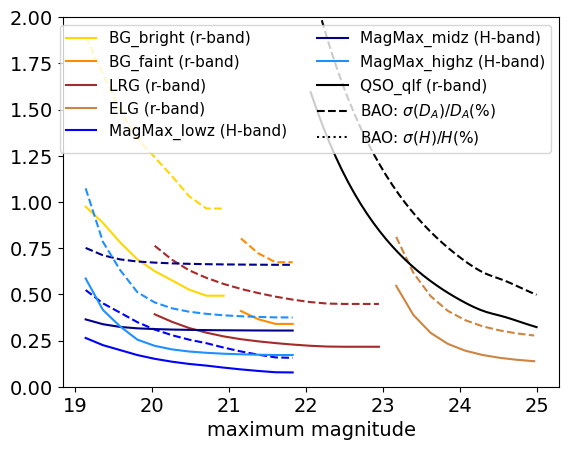

In [40]:
n=0
for k, tracer in enumerate(['BG_bright', 'BG_faint', 'LRG','ELG', 'MagMax_lowz','MagMax_midz','MagMax_highz', 'QSO_qlf']):
    
    survey = survey_design_grey
    if tracer == 'BG_bright':
        survey = survey_design_bright
        i =8
        #plt.errorbar(survey_design_bright['per_tracer_forecasts'][tracer+'_list_zbin_rsd'][i], survey_design_bright['per_tracer_forecasts'][tracer+'_list_sigma_rsd'][i], xerr=0.1)
    if tracer == 'BG_faint':
        survey = survey_design_grey
        i=3

    if tracer == 'LRG':
        survey = survey_design_grey
        i=12 #22.8

    if tracer == 'ELG':
        survey = survey_design_grey
        i=8 #25.3

    if tracer == 'QSO_qlf':
        survey = survey_design_dark_qso
        i=8 #25.3

    if 'MagMax' in tracer.split('_'):
        survey = survey_design_grey_MagMax
        i=11

    if tracer!='MagMax':
        n+=survey['config_survey'][tracer+'_target_density'][i]

    if tracer=='MagMax': 
        print(n)
    
    print(tracer, '=', survey['config_survey'][tracer+'_target_density'][i])

    mask_color = np.array(survey['config_survey']['tracers'])==tracer
   
    color = np.array(survey['config_survey']['color'])[mask_color][0]

    mask_index_tracer_in_survey = survey["config_survey"]['tracers'] == tracer

    #plt.fill_between(np.array(x), np.array(y), 0*np.array(y),  color=color, alpha=0.4)

    x, y = survey['config_survey'][tracer+'_mag_centers'], np.array(survey['per_tracer_forecasts'][tracer+'_sigma_Da_eff'])
    plt.plot(np.array(x)[y < 100],100* np.array(y)[y < 100],
                 color = color,label = tracer+ f' ({survey["config_survey"]["limiting_mag_band"][mask_index_tracer_in_survey]}-band)',
                 marker='', ls='-')
    #plt.fill_between(np.array(x), np.array(y), 0*np.array(y),  color=color, alpha=0.4)

    x, y = survey['config_survey'][tracer+'_mag_centers'], np.array(survey['per_tracer_forecasts'][tracer+'_sigma_H_eff'])
    plt.plot(np.array(x)[y < 10], 100*np.array(y)[y < 10],
                 color = color, 
                 marker='', ls='--')

        

    #plt.xlim(0, 1.3)
plt.ylim(0.000, 2)
plt.xlabel(r'maximum magnitude', fontsize=14)
plt.tick_params(axis='both', labelsize=14)
#lt.yscale('log')
plt.plot([], [], '--k', label = r'BAO: $\sigma(D_A)/D_A (\%)$')
plt.plot([], [], ':k', label = r'BAO: $\sigma(H)/H (\%)$')
plt.legend(fontsize=11, ncols=2)

In [33]:
sigma_omega_m = 10000.012
h_fid         = 0.677
sigma_H0      = 100.0 * 0.0054

F_prior = np.diag([
    1 / 1e6,                                  # w0  — essentially flat
    1 / 1e6,                                  # wa  — essentially flat
    (h_fid**2 / sigma_omega_m)**2,            # Omega_m, from omega_m prior
    1 / sigma_H0**2,                          # H0
])

n=0
for k, tracer in enumerate(['MagMax_lowz','MagMax_midz','MagMax_highz']):
    
    survey = survey_design_grey
    if tracer == 'BG_bright':
        survey = survey_design_bright
        i =8
        #plt.errorbar(survey_design_bright['per_tracer_forecasts'][tracer+'_list_zbin_rsd'][i], survey_design_bright['per_tracer_forecasts'][tracer+'_list_sigma_rsd'][i], xerr=0.1)
    if tracer == 'BG_faint':
        survey = survey_design_grey
        i=3

    if tracer == 'LRG':
        survey = survey_design_grey
        i=12 #22.8

    if tracer == 'ELG':
        survey = survey_design_grey
        i=8 #25.3

    if tracer == 'QSO_qlf':
        survey = survey_design_dark_qso
        i=8 #25.3

    if 'MagMax' in tracer.split('_'):
        survey = survey_design_grey_MagMax
        i=11

    if tracer!='MagMax':
        n+=survey['config_survey'][tracer+'_target_density'][i]

    if tracer=='MagMax': 
        print(n)

    x, y = survey['config_survey'][tracer+'_mag_centers'], 100*np.array(survey['per_tracer_forecasts'][tracer+'_sigma_Da_eff'])

    survey['per_tracer_forecasts'][tracer+'_sigma_w0_eff'] = []
    survey['per_tracer_forecasts'][tracer+'_sigma_wa_eff'] = []
    survey['per_tracer_forecasts'][tracer+'_Fisher_mat_wOwa_eff'] = []
    err_w0 = []
    err_wa = []
    for i in range(len(survey['per_tracer_forecasts'][tracer+'_zeff_Da'])):
        zeff = survey['per_tracer_forecasts'][tracer+'_zeff_Da'][i]
        sigma_Da_eff = survey['per_tracer_forecasts'][tracer+'_sigma_Da_eff'][i]
        sigma_H_eff = survey['per_tracer_forecasts'][tracer+'_sigma_H_eff'][i]
        corr = survey['per_tracer_forecasts'][tracer+'_rho_DaH_eff'][i]
        
        Fisher_mat_w0wa = fisher_matrix_bao_SuEisenstein.Fisher_mat_BAO_cosmo_params(zeff, sigma_Da_eff, sigma_H_eff, cosmo,  param_names=('w0', 'wa', 'Omega_m', 'H0'), corr_DaH=corr, rel_step=1e-2)
        Fisher_mat_wowa_plus_prior = Fisher_mat_w0wa + F_prior

        survey['per_tracer_forecasts'][tracer+'_Fisher_mat_wOwa_eff'].append(Fisher_mat_w0wa)
        err_w0.append(np.linalg.inv(Fisher_mat_wowa_plus_prior).diagonal()[0]**.5)
        err_wa.append(np.linalg.inv(Fisher_mat_wowa_plus_prior).diagonal()[1]**.5)
    survey['per_tracer_forecasts'][tracer+'_sigma_w0_eff'] = np.array(err_w0)
    survey['per_tracer_forecasts'][tracer+'_sigma_wa_eff'] = np.array(err_wa)

MagMax_lowz = 28297.02380952381
MagMax_midz = 28297.02380952381
MagMax_highz = 28297.02380952381


Text(0.5, 0, 'maximum magnitude')

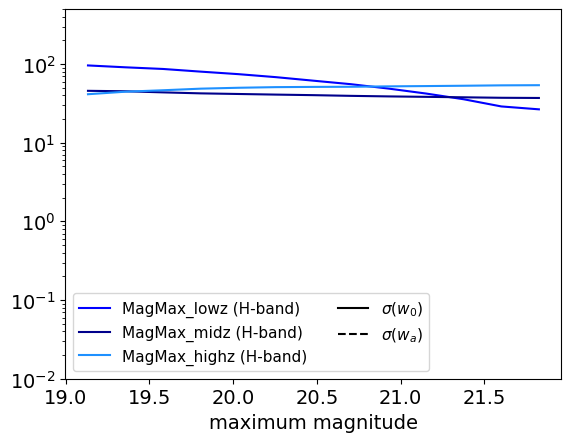

In [34]:
n=0
for k, tracer in enumerate(['MagMax_lowz','MagMax_midz','MagMax_highz']):
    
    survey = survey_design_grey
    if tracer == 'BG_bright':
        survey = survey_design_bright
        i =8
        #plt.errorbar(survey_design_bright['per_tracer_forecasts'][tracer+'_list_zbin_rsd'][i], survey_design_bright['per_tracer_forecasts'][tracer+'_list_sigma_rsd'][i], xerr=0.1)
    if tracer == 'BG_faint':
        survey = survey_design_grey
        i=3

    if tracer == 'LRG':
        survey = survey_design_grey
        i=12 #22.8

    if tracer == 'ELG':
        survey = survey_design_grey
        i=8 #25.3

    if 'MagMax' in tracer.split('_'):
        survey = survey_design_grey_MagMax
        i=11

    if tracer == 'QSO_qlf':
        survey = survey_design_dark_qso
        i=8 #25.3
        
    if tracer!='MagMax':
        n+=survey['config_survey'][tracer+'_target_density'][i]

    if tracer=='MagMax': 
        print(n)
    
    print(tracer, '=', survey['config_survey'][tracer+'_target_density'][i])

    mask_color = np.array(survey['config_survey']['tracers'])==tracer
   
    color = np.array(survey['config_survey']['color'])[mask_color][0]

    x, y = survey['config_survey'][tracer+'_mag_centers'], np.array(survey['per_tracer_forecasts'][tracer+'_sigma_w0_eff'])
    
    mask_index_tracer_in_survey = survey["config_survey"]['tracers'] == tracer
    plt.plot(np.array(x)[y < 1000], np.array(y)[y < 1000],
                 color = color, 
                 marker='',label = tracer+ f' ({survey["config_survey"]["limiting_mag_band"][mask_index_tracer_in_survey]}-band)')

    x, y = survey['config_survey'][tracer+'_mag_centers'], np.array(survey['per_tracer_forecasts'][tracer+'_sigma_wa_eff'])
    plt.plot(np.array(x)[y < 1000], np.array(y)[y < 1000],
                 color = color, ls='--',
                 marker='')

    #plt.xlim(0, 1.3)
    plt.ylim(0.01, 500)
plt.xlabel(r'redshift bin', fontsize=14)
plt.tick_params(axis='both', labelsize=14)
plt.yscale('log')
plt.plot([], [], '-k', label = r'$\sigma(w_0)$')
plt.plot([], [], '--k', label = r'$\sigma(w_a)$')
plt.legend(fontsize=11, ncols=2)
plt.xlabel(r'maximum magnitude', fontsize=14)

In [28]:
sigma_omega_m = 10000.012
h_fid         = 0.677
sigma_H0      = 100.0 * 0.0054

F_prior = np.diag([
    1 / 1e6,                                  # w0  — essentially flat
    1 / 1e6,                                  # wa  — essentially flat
    (h_fid**2 / sigma_omega_m)**2,            # Omega_m, from omega_m prior
    1 / sigma_H0**2,                          # H0
])

n=0
for k, tracer in enumerate(['BG_bright', 'BG_faint', 'LRG','ELG', 'MagMax_lowz','MagMax_midz','MagMax_highz','QSO_qlf']):
    
    survey = survey_design_grey
    if tracer == 'BG_bright':
        survey = survey_design_bright
        i =8
        #plt.errorbar(survey_design_bright['per_tracer_forecasts'][tracer+'_list_zbin_rsd'][i], survey_design_bright['per_tracer_forecasts'][tracer+'_list_sigma_rsd'][i], xerr=0.1)
    if tracer == 'BG_faint':
        survey = survey_design_grey
        i=3

    if tracer == 'LRG':
        survey = survey_design_grey
        i=12 #22.8

    if tracer == 'ELG':
        survey = survey_design_grey
        i=8 #25.3

    if tracer == 'QSO_qlf':
        survey = survey_design_dark_qso
        i=8 #25.3

    if 'MagMax' in tracer.split('_'):
        survey = survey_design_grey_MagMax
        i=11

    if tracer!='MagMax':
        n+=survey['config_survey'][tracer+'_target_density'][i]

    if tracer=='MagMax': 
        print(n)

    x, y = survey['config_survey'][tracer+'_mag_centers'], 100*np.array(survey['per_tracer_forecasts'][tracer+'_sigma_Da_eff'])

    survey['per_tracer_forecasts'][tracer+'_sigma_w0_eff'] = []
    survey['per_tracer_forecasts'][tracer+'_sigma_wa_eff'] = []
    survey['per_tracer_forecasts'][tracer+'_Fisher_mat_wOwa_eff'] = []
    err_w0 = []
    err_wa = []
    for i in range(len(survey['per_tracer_forecasts'][tracer+'_zeff_Da'])):
        zeff = survey['per_tracer_forecasts'][tracer+'_zeff_Da'][i]
        sigma_Da_eff = survey['per_tracer_forecasts'][tracer+'_sigma_Da_eff'][i]
        sigma_H_eff = survey['per_tracer_forecasts'][tracer+'_sigma_H_eff'][i]
        
        Fisher_mat_w0wa = fisher_matrix_bao_SuEisenstein.Fisher_mat_BAO_cosmo_params(zeff, sigma_Da_eff, sigma_H_eff, cosmo,  param_names=('w0', 'wa', 'Omega_m', 'H0'), rel_step=1e-2)
        Fisher_mat_wowa_plus_prior = Fisher_mat_w0wa + F_prior

        survey['per_tracer_forecasts'][tracer+'_Fisher_mat_wOwa_eff'].append(Fisher_mat_w0wa)
        err_w0.append(np.linalg.inv(Fisher_mat_wowa_plus_prior).diagonal()[0]**.5)
        err_wa.append(np.linalg.inv(Fisher_mat_wowa_plus_prior).diagonal()[1]**.5)
    survey['per_tracer_forecasts'][tracer+'_sigma_w0_eff'] = np.array(err_w0)
    survey['per_tracer_forecasts'][tracer+'_sigma_wa_eff'] = np.array(err_wa)

/tmp/ipykernel_2612829/3118014728.py:62: RuntimeWarning: invalid value encountered in scalar power
  err_w0.append(np.linalg.inv(Fisher_mat_wowa_plus_prior).diagonal()[0]**.5)


LinAlgError: Singular matrix

BG_bright = 2905.251641137855
BG_faint = 4250.929978118162
LRG = 2508.807439824945
ELG = 16491.65827385383
MagMax_lowz = 28297.02380952381
MagMax_midz = 28297.02380952381
MagMax_highz = 28297.02380952381
QSO_qlf = 117.97406612343022


Text(0.5, 0, 'maximum magnitude')

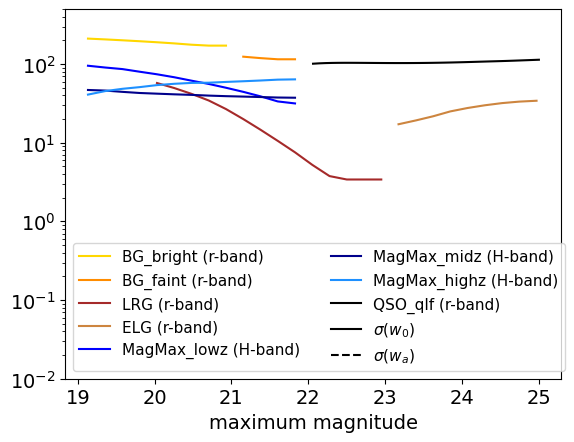

In [26]:
n=0
for k, tracer in enumerate(['BG_bright', 'BG_faint', 'LRG','ELG', 'MagMax_lowz','MagMax_midz','MagMax_highz','QSO_qlf']):
    
    survey = survey_design_grey
    if tracer == 'BG_bright':
        survey = survey_design_bright
        i =8
        #plt.errorbar(survey_design_bright['per_tracer_forecasts'][tracer+'_list_zbin_rsd'][i], survey_design_bright['per_tracer_forecasts'][tracer+'_list_sigma_rsd'][i], xerr=0.1)
    if tracer == 'BG_faint':
        survey = survey_design_grey
        i=3

    if tracer == 'LRG':
        survey = survey_design_grey
        i=12 #22.8

    if tracer == 'ELG':
        survey = survey_design_grey
        i=8 #25.3

    if 'MagMax' in tracer.split('_'):
        survey = survey_design_grey_MagMax
        i=11

    if tracer == 'QSO_qlf':
        survey = survey_design_dark_qso
        i=8 #25.3
        
    if tracer!='MagMax':
        n+=survey['config_survey'][tracer+'_target_density'][i]

    if tracer=='MagMax': 
        print(n)
    
    print(tracer, '=', survey['config_survey'][tracer+'_target_density'][i])

    mask_color = np.array(survey['config_survey']['tracers'])==tracer
   
    color = np.array(survey['config_survey']['color'])[mask_color][0]

    x, y = survey['config_survey'][tracer+'_mag_centers'], np.array(survey['per_tracer_forecasts'][tracer+'_sigma_w0_eff'])
    
    mask_index_tracer_in_survey = survey["config_survey"]['tracers'] == tracer
    plt.plot(np.array(x)[y < 1000], np.array(y)[y < 1000],
                 color = color, 
                 marker='',label = tracer+ f' ({survey["config_survey"]["limiting_mag_band"][mask_index_tracer_in_survey]}-band)')

    x, y = survey['config_survey'][tracer+'_mag_centers'], np.array(survey['per_tracer_forecasts'][tracer+'_sigma_wa_eff'])
    plt.plot(np.array(x)[y < 1000], np.array(y)[y < 1000],
                 color = color, ls='--',
                 marker='')

    #plt.xlim(0, 1.3)
    plt.ylim(0.01, 500)
plt.xlabel(r'redshift bin', fontsize=14)
plt.tick_params(axis='both', labelsize=14)
plt.yscale('log')
plt.plot([], [], '-k', label = r'$\sigma(w_0)$')
plt.plot([], [], '--k', label = r'$\sigma(w_a)$')
plt.legend(fontsize=11, ncols=2)
plt.xlabel(r'maximum magnitude', fontsize=14)

In [35]:
plt.figure(figsize=(12, 4))




n=0
x = survey_design_grey['config_survey']['ELG_mag_centers']
Fisher_tot = np.zeros([4,4])
for k, tracer in enumerate(['BG_bright', 'BG_faint', 'LRG']):
        
        survey = survey_design_grey
        if tracer == 'BG_bright':
            survey = survey_design_bright
            i = 8
        if tracer == 'BG_faint':
            survey = survey_design_grey
            i= 3
        if tracer == 'LRG':
            survey = survey_design_grey
            i= 12 #22.8
    
        #n+=survey['config_survey'][tracer+'_target_density'][i]
        print(tracer, '=', survey['config_survey'][tracer+'_target_density'][i])
        Fisher_tot += survey['per_tracer_forecasts'][tracer+'_Fisher_mat_wOwa_eff'][i]

#Fisher_tot += survey_design_dark_qso['per_tracer_forecasts']['QSO_qlf_Fisher_mat_wOwa_eff'][30]
err_w0 = []
err_wa = []
#Fisher_tot += survey_design_dark_qso['per_tracer_forecasts']['QSO_qlf_Fisher_mat_wOwa_eff'][30]
for i in range(len(x)):
    Fisher_tot_x = survey_design_grey['per_tracer_forecasts']['ELG_Fisher_mat_wOwa_eff'][i]
    print('ELG', '=', survey_design_grey['config_survey']['ELG_target_density'][i])
    err_w0.append(np.linalg.inv(Fisher_tot + Fisher_tot_x + F_prior).diagonal()[0]**.5)
    err_wa.append(np.linalg.inv(Fisher_tot + Fisher_tot_x + F_prior).diagonal()[1]**.5)
plt.subplot(121)
plt.plot(n+x, np.array(err_w0), '-', color='darkorange', label = 'ELG (+BG+LRG)', lw=2)
plt.subplot(122)
plt.plot(n+x, np.array(err_wa), '-', color='darkorange', label = 'ELG (+BG+LRG)', lw=2)
del err_w0, err_wa




x = survey_design_grey_MagMax['config_survey']['MagMax_mag_centers']
err_w0 = []
err_wa = []
for i in range(len(x)):
    Fisher_tot_ = 0
    for k, tracer in enumerate(['MagMax_lowz', 'MagMax_midz', 'MagMax_highz']):

        Fisher_tot_ += survey_design_grey_MagMax['per_tracer_forecasts'][tracer+'_Fisher_mat_wOwa_eff'][i]
    #Fisher_tot_ += survey_design_dark_qso['per_tracer_forecasts']['QSO_qlf_Fisher_mat_wOwa_eff'][30]
    err_w0.append(np.linalg.inv(Fisher_tot_ + F_prior).diagonal()[0]**.5)
    err_wa.append(np.linalg.inv(Fisher_tot_ + F_prior).diagonal()[1]**.5)
plt.subplot(121)
plt.plot(x, np.array(err_w0), '-', color='darkblue', label = 'MagMax', lw=2)
plt.subplot(122)
plt.plot(x, np.array(err_wa), '-', color='darkblue', label = 'MagMax', lw=2)


n=0
x = survey_design_grey['config_survey']['ELG_mag_centers']
Fisher_tot = np.zeros([4,4])
for k, tracer in enumerate(['BG_bright', 'BG_faint', 'LRG']):
        
        survey = survey_design_grey
        if tracer == 'BG_bright':
            survey = survey_design_bright
            i = 8
        if tracer == 'BG_faint':
            survey = survey_design_grey
            i= 3
        if tracer == 'LRG':
            survey = survey_design_grey
            i= 12 #22.8
    
        #n+=survey['config_survey'][tracer+'_target_density'][i]
        print(tracer, '=', survey['config_survey'][tracer+'_target_density'][i])
        Fisher_tot += survey['per_tracer_forecasts'][tracer+'_Fisher_mat_wOwa_eff'][i]

Fisher_tot += survey_design_dark_qso['per_tracer_forecasts']['QSO_qlf_Fisher_mat_wOwa_eff'][30]
err_w0 = []
err_wa = []
#Fisher_tot += survey_design_dark_qso['per_tracer_forecasts']['QSO_qlf_Fisher_mat_wOwa_eff'][30]
for i in range(len(x)):
    Fisher_tot_x = survey_design_grey['per_tracer_forecasts']['ELG_Fisher_mat_wOwa_eff'][i]
    print('ELG', '=', survey_design_grey['config_survey']['ELG_target_density'][i])
    err_w0.append(np.linalg.inv(Fisher_tot + Fisher_tot_x + F_prior).diagonal()[0]**.5)
    err_wa.append(np.linalg.inv(Fisher_tot + Fisher_tot_x + F_prior).diagonal()[1]**.5)
plt.subplot(121)
plt.plot(n+x, np.array(err_w0), '--', color='darkorange', label = 'ELG (+BG+LRG+QSO)', lw=2)
plt.subplot(122)
plt.plot(n+x, np.array(err_wa), '--', color='darkorange', label = 'ELG (+BG+LRG+QSO)', lw=2)
del err_w0, err_wa




x = survey_design_grey_MagMax['config_survey']['MagMax_mag_centers']
err_w0 = []
err_wa = []
for i in range(len(x)):
    Fisher_tot_ = 0
    for k, tracer in enumerate(['MagMax_lowz', 'MagMax_midz', 'MagMax_highz']):

        Fisher_tot_ += survey_design_grey_MagMax['per_tracer_forecasts'][tracer+'_Fisher_mat_wOwa_eff'][i]
    Fisher_tot_ += survey_design_dark_qso['per_tracer_forecasts']['QSO_qlf_Fisher_mat_wOwa_eff'][30]
    err_w0.append(np.linalg.inv(Fisher_tot_ + F_prior).diagonal()[0]**.5)
    err_wa.append(np.linalg.inv(Fisher_tot_ + F_prior).diagonal()[1]**.5)
plt.subplot(121)
plt.plot(x, np.array(err_w0), '--', color='darkblue', label = 'MagMax (+ QSO)', lw=2)
plt.subplot(122)
plt.plot(x, np.array(err_wa), '--', color='darkblue', label = 'MagMax (+ QSO)', lw=2)


plt.subplot(121)
plt.ylabel(r'$\sigma(w_0)$', fontsize=14)
plt.xlabel(r'$m < m_{max}$ (ELG or MagMax)', fontsize=14)
#plt.ylim(0.8, 1)
plt.grid(which='both')
plt.legend(fontsize=11, loc='upper right', ncols=2)
plt.tick_params(axis='both', labelsize=14)

plt.subplot(122)
plt.ylabel(r'$\sigma(w_a)$', fontsize=14)
plt.xlabel(r'$m < m_{max}$ (ELG or MagMax)', fontsize=14)
#plt.ylim(0.8, 1)
plt.grid(which='both')
plt.legend(fontsize=11, loc='upper right', ncols=2)
plt.tick_params(axis='both', labelsize=14)

BG_bright = 2905.251641137855


KeyError: 'BG_bright_Fisher_mat_wOwa_eff'

<Figure size 1200x400 with 0 Axes>

BG_bright = 2905.251641137855
BG_faint = 4250.929978118162
LRG = 2508.807439824945
ELG = 441.3889740333669
ELG = 767.7599217643882
ELG = 1359.7816409043803
ELG = 2323.714440016932
ELG = 3790.9240851834015
ELG = 5890.440951088147
ELG = 8682.985214053217
ELG = 12240.954007385675
ELG = 16491.65827385383


/tmp/ipykernel_2612829/188237393.py:57: MatplotlibDeprecationWarning: Passing the emit parameter of set_xlim() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases later.
  plt.xlim(9000, 30000, 5e4)


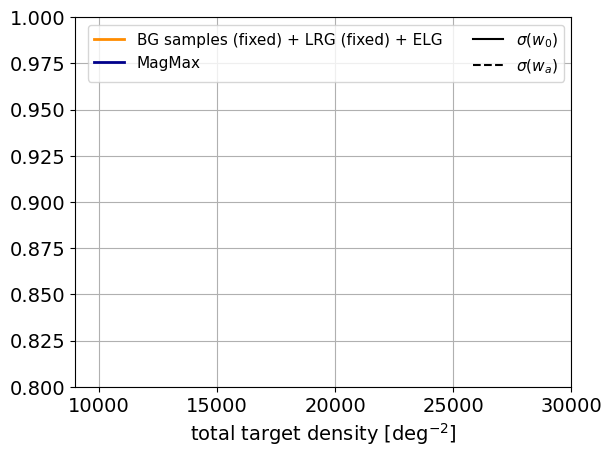

In [16]:
n=0
x = survey_design_grey['config_survey']['ELG_target_density']
Fisher_tot = np.zeros([4,4])
for k, tracer in enumerate(['BG_bright', 'BG_faint', 'LRG']):
        
        survey = survey_design_grey
        if tracer == 'BG_bright':
            survey = survey_design_bright
            i = 8
        if tracer == 'BG_faint':
            survey = survey_design_grey
            i= 3
        if tracer == 'LRG':
            survey = survey_design_grey
            i= 12 #22.8
    
        n+=survey['config_survey'][tracer+'_target_density'][i]
        print(tracer, '=', survey['config_survey'][tracer+'_target_density'][i])
        Fisher_tot += survey['per_tracer_forecasts'][tracer+'_Fisher_mat_wOwa_eff'][i]

Fisher_tot += survey_design_dark_qso['per_tracer_forecasts']['QSO_qlf_Fisher_mat_wOwa_eff'][30]
err_w0 = []
err_wa = []
#Fisher_tot += survey_design_dark_qso['per_tracer_forecasts']['QSO_qlf_Fisher_mat_wOwa_eff'][30]
for i in range(len(x)):
    Fisher_tot_x = survey_design_grey['per_tracer_forecasts']['ELG_Fisher_mat_wOwa_eff'][i]
    print('ELG', '=', survey_design_grey['config_survey']['ELG_target_density'][i])
    err_w0.append(np.linalg.inv(Fisher_tot + Fisher_tot_x + F_prior).diagonal()[0]**.5)
    err_wa.append(np.linalg.inv(Fisher_tot + Fisher_tot_x + F_prior).diagonal()[1]**.5)
plt.plot(n+x, np.array(err_w0)/0.03, '-', color='darkorange', label = 'BG samples (fixed) + LRG (fixed) + ELG', lw=2)
plt.plot(n+x, np.array(err_wa)/0.09, '--', color='darkorange', lw=2)
del err_w0, err_wa




x = survey_design_grey_MagMax['config_survey']['MagMax_target_density']
err_w0 = []
err_wa = []
for i in range(len(x)):
    Fisher_tot_ = 0
    for k, tracer in enumerate(['MagMax_lowz', 'MagMax_midz', 'MagMax_highz']):

        Fisher_tot_ += survey_design_grey_MagMax['per_tracer_forecasts'][tracer+'_Fisher_mat_wOwa_eff'][i]
    #Fisher_tot_ += survey_design_dark_qso['per_tracer_forecasts']['QSO_qlf_Fisher_mat_wOwa_eff'][30]
    err_w0.append(np.linalg.inv(Fisher_tot_ + F_prior).diagonal()[0]**.5)
    err_wa.append(np.linalg.inv(Fisher_tot_ + F_prior).diagonal()[1]**.5)

plt.plot(x, np.array(err_w0)/0.03, '-', color='darkblue', label = 'MagMax', lw=2)
plt.plot(x, np.array(err_wa)/0.09, '--', color='darkblue', lw=2)
#plt.xscale('log')
plt.plot([], [], '-k', label = r'$\sigma(w_0)$')
plt.plot([], [], '--k', label = r'$\sigma(w_a)$')
plt.xlabel(r'total target density [deg$^{-2}$]', fontsize=14)
#plt.yscale('log')
plt.ylim(0.8, 1)
plt.xlim(9000, 30000, 5e4)
plt.grid(which='both')
plt.legend(fontsize=11, loc='upper right', ncols=2)
plt.tick_params(axis='both', labelsize=14)